# Fine-tuning a judge to match human labels

Your regression gates, your eval dashboards, and half your release decisions inherit the quality of
one LLM judge. If that judge disagrees with the people who own quality, every number downstream is
confidently wrong.

This notebook takes a judge from "prompted frontier model" to "fine-tuned small model" and measures
whether that trade is worth making, on three axes: **agreement**, **calibration**, and **cost**.

The pipeline:

1. **Traces** — a real LangGraph agent (`ChatFireworks`) answers SQL questions over a demo store,
   under four conditions that make it succeed, fumble, and hallucinate.
2. **Gold set** — a three-annotator panel labels every trace on a 1–5 rubric. Leave-one-out
   annotator-vs-consensus agreement is the **ceiling**: a judge above it is fitting the panel.
3. **Prompted baseline** — three rounds of rubric iteration, with few-shot examples pulled from the
   judge's own disagreements. Kappa *and* ECE tracked at every round.
4. **Fine-tune** — LoRA SFT on a small model, deployed on-demand.
5. **Compare** — kappa against the ceiling, reliability diagrams, latency, dollars per 1k judgments.

### Read this before you trust any number below

The traces are real. **The annotators are not.** They are one frontier model prompted as three
reviewers who weight the rubric differently. That substitution is what makes this notebook runnable
end-to-end in one sitting, and it buys two things a single synthetic label cannot: a real
inter-annotator ceiling, and a soft label distribution to measure calibration against.

It also has a limit worth stating plainly: **a judge fine-tuned on an LLM panel distills that
panel, blind spots included.** Point `label_panel.load()` at your own 100–200 hand-labeled traces
and everything downstream runs unchanged.

## 1. Setup

Needs `FIREWORKS_API_KEY` and `FIREWORKS_ACCOUNT_ID` in a repo-root `.env`.

**Run it cheaply first.** `export JUDGE_ALIGN_SMOKE=1` shrinks the gold set to 24 traces and writes
to `data_smoke/`, so you can validate the whole pipeline and your credentials for a few cents.
Unset it for the real run.

Sections 1–5 are inference only. Training and deployment are gated behind an explicit confirmation
cell in section 6, and the last cell tears the deployment down.

In [1]:
# %pip install -q fireworks-ai langchain-fireworks langgraph openai scikit-learn scipy matplotlib python-dotenv

# The helper modules next to this notebook are meant to be edited while you work.
# Without autoreload, Python caches the version imported at kernel start and your
# fixes silently do not apply -- which looks exactly like the fix not working.
%load_ext autoreload
%autoreload 2

import json
import os
import sys
import time
import uuid
from pathlib import Path

import dotenv
import numpy as np

dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True), override=True)  # repo-root .env

# The helper modules live next to this notebook.
_HERE = Path.cwd()
while _HERE != _HERE.parent and not (_HERE / "agent_traces.py").exists():
    _HERE = _HERE.parent
sys.path.insert(0, str(_HERE))

from fireworks import Fireworks, file_from_path
from openai import OpenAI

assert os.getenv("FIREWORKS_API_KEY"), "FIREWORKS_API_KEY missing from .env"
ACCOUNT_ID = os.getenv("FIREWORKS_ACCOUNT_ID", "").replace("accounts/", "", 1)
assert ACCOUNT_ID, "FIREWORKS_ACCOUNT_ID missing from .env"

client = Fireworks()                       # control plane: datasets, jobs, deployments
oai = OpenAI(api_key=os.environ["FIREWORKS_API_KEY"],
             base_url="https://api.fireworks.ai/inference/v1")   # data plane: judge calls

print("account:", ACCOUNT_ID)

account: pyroworks


In [2]:
# ----------------------------------------------------------------------------- CONFIG
# Agents that produce the traces. Two different families so the failure modes differ.
STRONG_AGENT = "accounts/fireworks/models/kimi-k3"
WEAK_AGENT   = "accounts/fireworks/models/gpt-oss-20b"

# The stand-in annotator panel. Deliberately NOT the same model as the baseline judge:
# a judge grading against labels from its own family gets a free self-agreement bonus.
PANEL_MODEL  = "accounts/fireworks/models/deepseek-v4-pro"

# The prompted baseline we are trying to beat.
BASELINE_JUDGE = "accounts/fireworks/models/glm-5p2"

# The model we fine-tune. `-instruct-2507` is the non-thinking Qwen3 variant, and that is a
# hard requirement rather than a preference: a reasoning preamble breaks the `stop=["}"]`
# trick below, and it hands back the latency and cost win that justifies the whole exercise.
#
# A mixture-of-experts with ~3B active parameters, so it buys a large capacity increase
# over a 4b at close to the same inference speed -- which is what keeps the cheap-judge
# argument intact.
#
# Do not trust the `tunable` field on the models API when picking a base model: it is a
# legacy training-V1 flag, and every V2-only model reports `tunable=false` while being
# perfectly fine-tunable. Check the model page, not the field.
STUDENT_MODEL = "accounts/fireworks/models/qwen3p6-35b-a3b"
# STUDENT_MODEL = "accounts/fireworks/models/qwen3-30b-a3b-instruct-2507"
# STUDENT_MODEL = "accounts/fireworks/models/qwen3-4b-instruct-2507"

ATTRIBUTES = ["correctness", "efficiency", "tool_use"]

# SMOKE mode runs the whole notebook on a tiny set so you can validate the pipeline
# (and your credentials) for a few cents before committing to the real run.
#   export JUDGE_ALIGN_SMOKE=1
SMOKE = os.getenv("JUDGE_ALIGN_SMOKE") == "1"
N_TRACES = 24 if SMOKE else 200     # gold set size; 100-200 is the useful range
CONCURRENCY = 12

# Prices per MILLION tokens. These change -- check https://fireworks.ai/pricing and your own
# deployment's GPU-hour rate before quoting the cost column to anyone.
PRICES = {
    BASELINE_JUDGE: (0.55, 2.19),
    "deployed":     (0.10, 0.10),   # small on-demand LoRA; dominated by GPU-hour, see section 7
}

# How to turn three annotator opinions into training labels.
#   False -> one row per trace, labelled with the panel median (the denoised target)
#   True  -> one row per annotator, so the model sees the disagreement itself
# See the discussion in section 6; this is the knob that controls whether the judge
# can learn *when to be unsure*.
#   "median" -> one row per trace, labelled with the panel median (the denoised target)
#   "votes"  -> one row per annotator, so the model sees the disagreement itself
# Both are trained and evaluated below, one after the other, so you get the comparison
# rather than having to pick. Drop one from the list to halve the cost.
LABEL_MODES = ["median", "votes"]

# Training hyperparameters. Vote mode triples the row count, so it gets fewer epochs to
# keep the number of gradient steps (and the bill) roughly comparable.
EPOCHS = {"median": 3, "votes": 2}
LORA_RANK, LEARNING_RATE, BATCH_SIZE_SAMPLES = 16, 1e-4, 8
ACCELERATOR_TYPE = "NVIDIA_H100_80GB"
# A 35B MoE plus a LoRA addon does not fit the minimum KV + state pools on 2 GPUs:
#   Can't allocate minimal cache pools: min_kv=2.78 GiB + min_state=15.35 GiB
#   = 18.13 GiB exceeds total cache budget -3.49 GiB
ACCELERATOR_COUNT = 8

# The tuned judge emits ~21 tokens of JSON, then -- if the fine-tune has not learned to
# stop -- keeps going until it hits the cap. `stop=["}"]` ends generation at the close of
# the object, which is most of the latency and cost: measured 0.74s/128 tokens without it
# versus 0.22s/21 tokens with it, same scores. The cap is the backstop if `stop` misses.
#
# Only safe for a non-reasoning judge. A thinking model would trip the stop on a brace in
# its preamble, before the answer exists -- hence no stop sequence on the baseline.
TUNED_MAX_TOKENS = 128
TUNED_STOP = ["}"]

# Stable per-run ids. Pin RUN (e.g. export JUDGE_ALIGN_RUN=abc123) to resume a run
# instead of creating a second dataset/job/deployment for the same work.
RUN = os.getenv("JUDGE_ALIGN_RUN") or uuid.uuid4().hex[:6]
# Tag resources with the model size and label mode so the two variants are
# distinguishable in the console instead of being six random hex characters.
SIZE = STUDENT_MODEL.split("/")[-1].split("-")[1]          # e.g. "35b", "30b", "4b"
def variant(mode):    return f"{SIZE}-{mode}"
def res_id(mode):     return f"judge-align-{variant(mode)}-{RUN}"

DATA = _HERE / ("data_smoke" if SMOKE else "data"); DATA.mkdir(exist_ok=True)
TRACES_FILE   = DATA / "traces.jsonl"
LABELED_FILE  = DATA / "labeled.jsonl"
DB_FILE       = DATA / "store.sqlite"
HOLDOUT_FILE  = DATA / "judge_holdout.jsonl"
def train_file(mode): return DATA / f"judge_train_{mode}.jsonl"
# Results accumulate here across runs, so changing STUDENT_MODEL and re-running adds
# rows to the comparison matrix instead of overwriting the last answer.
RESULTS_FILE  = DATA / "results.jsonl"

print(f"run id: {RUN}   student: {SIZE}   label modes: {LABEL_MODES}")

run id: c9178b   student: 35b   label modes: ['median', 'votes']


## 2. Traces: a real agent, failing in real ways

Hand-written traces cannot produce the distribution a judge actually has to grade. So we run an
actual `create_react_agent` over a small SQLite store with three tools (`run_sql`,
`describe_schema`, `calculator`) under four conditions:

| tier | share | what is different | what it produces |
| --- | --- | --- | --- |
| `strong` | 17% | capable model, clean prompt, all tools | mostly correct, sometimes over-verifies |
| `stale_schema` | 25% | prompt describes a **pre-migration schema** | real SQL errors, recovery, subtly wrong filters |
| `stale_data` | 33% | queries a **replica missing recent rows** | flawless method, wrong number |
| `no_tools` | 8% | tools removed — the retrieval layer is "down" | refusals, or confident invented numbers |
| `flaky` | 17% | the SQL tool fails on first call | retries, or giving up and guessing |

The two `stale_*` tiers are the interesting ones, and they exist to solve a specific problem: a gold
set of only clean successes and total failures is **all 1s and 5s**, and every judge looks excellent
on it because telling a disaster from a clean run is not the job you are trying to measure.

`stale_data` is the sharper of the two. The agent's method is perfect and its answer is wrong, which
forces `correctness` and `tool_use` apart instead of letting them move together. Several questions
also ask for two things ("which category, and how many units"), so an agent can get the label right
and the quantity wrong — a 3, not a 1 and not a 5.

**The shares are deliberately not uniform**, for the same reason: `strong` is nearly always a 5 and
`no_tools` is nearly always a 1, so sampling all five tiers equally spends the budget on cases nobody
disagrees about. This is stratifying an eval set toward the decision boundary, not mirroring
production traffic. Some easy cases stay in — without them the scale has no anchors. The sampler also
pairs `stale_data` only with the ~10 questions whose answer actually changes on the stale replica;
random pairing would waste most of the tier on questions it gets right anyway. See
`agent_traces.build_tiers` and `_stratify`.

In [3]:
import agent_traces
from agent_traces import render_trace

if TRACES_FILE.exists():
    traces = agent_traces.load(TRACES_FILE)
    print(f"loaded {len(traces)} cached traces (delete {TRACES_FILE} to regenerate)")
else:
    t0 = time.time()
    traces = agent_traces.generate(
        TRACES_FILE, DB_FILE,
        strong_model=STRONG_AGENT, weak_model=WEAK_AGENT,
        n_traces=N_TRACES, concurrency=CONCURRENCY,
    )
    print(f"generated {len(traces)} traces in {time.time() - t0:.0f}s")

from collections import Counter
print("by tier:", dict(Counter(t["tier"] for t in traces)))
print("aborted:", sum(1 for t in traces if t.get("aborted")))

loaded 200 cached traces (delete /Users/sinan/cookbook-casestudies/training/case-studies/sft_judge_alignment/data/traces.jsonl to regenerate)
by tier: {'stale_data': 67, 'stale_schema': 50, 'no_tools': 17, 'flaky': 33, 'strong': 33}
aborted: 0


In [4]:
# One trace per tier, so you can see what the annotators are being asked to grade.
seen = set()
for t in traces:
    if t["tier"] in seen:
        continue
    seen.add(t["tier"])
    print("=" * 100)
    print(f"[{t['tier']}]  true answer: {t['gold_answer']}   agent answered: {t['answer'][:90]!r}")
    print("-" * 100)
    print(render_trace(t["trace"])[:1200])

[stale_data]  true answer: 203686.73   agent answered: "The total revenue from shipped orders placed by 'pro' tier customers is **144,011.39**."
----------------------------------------------------------------------------------------------------
USER: What is the total revenue from shipped orders placed by 'pro' tier customers? Round to 2 decimals.
  -> CALL run_sql({"query": "SELECT ROUND(SUM(oi.quantity * p.unit_price), 2) AS total_revenue\nFROM orders o\nJOIN customers c ON c.customer_id = o.customer_id\nJOIN order_items oi ON oi.order_id = o.order_id\nJOIN products p ON p.product_id = oi.product_id\nWHERE o.status = 'shipped'\n  AND c.tier = 'pro';"})
TOOL RESULT: total_revenue
144011.39
ASSISTANT: The total revenue from shipped orders placed by 'pro' tier customers is **144,011.39**.
[stale_schema]  true answer: 8   agent answered: 'There are **8 customers** based in Japan (JP).'
----------------------------------------------------------------------------------------------------
U

## 3. The gold set, and the ceiling

Three annotators, same rubric, different emphasis — strict/correctness-first, pragmatic/outcome-first,
and process-focused. Each grades every trace independently at `temperature=0.8`, because annotators
who always agree would report a ceiling of 1.0 and teach you nothing.

Two things come out of this:

- **`gold`** — the per-attribute median, the label a team would settle on in adjudication.
- **`dist`** — how the panel split. This is the target for calibration: on a trace where the panel
  went 4/4/2, a judge emitting 0.99 on "4" is overconfident even though its argmax is right.

Annotators see the true answer. That is deliberate and matches how offline eval sets actually work,
and it has a visible consequence below: `correctness` becomes close to objective (high ceiling),
while `efficiency` and `tool_use` stay genuinely subjective (lower ceiling). **The judge gets the
same information**, so the comparison stays fair.

In [5]:
import label_panel

if LABELED_FILE.exists():
    labeled = label_panel.load(LABELED_FILE)
    print(f"loaded {len(labeled)} cached labeled traces")
else:
    # 3 personas x N traces, and the panel model reasons before answering -- budget
    # roughly 30-40 minutes for a 200-trace gold set. Results are cached to disk, so
    # you pay this once.
    t0 = time.time()
    print(f"labeling {len(traces)} traces x {len(label_panel.PERSONAS)} annotators "
          f"= {len(traces) * len(label_panel.PERSONAS)} calls ...")
    raw = label_panel.label_traces(traces, oai, PANEL_MODEL, concurrency=max(CONCURRENCY, 24))
    labeled = label_panel.aggregate(raw)
    label_panel.save(labeled, LABELED_FILE)
    print(f"labeled {len(labeled)} traces in {time.time() - t0:.0f}s")

gold = [r["gold"] for r in labeled]
for a in ATTRIBUTES:
    counts = Counter(g[a] for g in gold)
    bar = "  ".join(f"{s}:{counts.get(s, 0):>3d}" for s in range(1, 6))
    print(f"{a:<13s} {bar}")

# A gold set that is all 1s and 5s makes every judge look excellent: telling a
# disaster from a clean run is not the job you are trying to measure. Check the
# middle of the scale is populated before believing any kappa below.
print()
for a in ATTRIBUTES:
    counts = Counter(g[a] for g in gold)
    mid = sum(counts.get(s, 0) for s in (2, 3, 4)) / len(gold)
    flag = "" if mid >= 0.25 else "   <-- DEGENERATE: too few mid-scale labels, kappa will be inflated"
    print(f"{a:<13s} {mid:.0%} of labels are 2-4{flag}")

loaded 192 cached labeled traces
correctness   1: 40  2:  0  3: 38  4:  0  5:114
efficiency    1: 12  2:  3  3:  8  4: 46  5:123
tool_use      1: 12  2:  2  3: 15  4: 48  5:115

correctness   20% of labels are 2-4   <-- DEGENERATE: too few mid-scale labels, kappa will be inflated
efficiency    30% of labels are 2-4
tool_use      34% of labels are 2-4


In [6]:
ceil = label_panel.ceiling(labeled)
print("ANNOTATOR AGREEMENT CEILINGS (quadratic-weighted kappa)")
print("-" * 72)
print(f"  {'':<13s} {'pairwise':>10s} {'vs consensus':>14s}")
for a in ATTRIBUTES:
    print(f"  {a:<13s} {ceil['pairwise'][a]:>+10.3f} {ceil['consensus'][a]:>+14.3f}")
print(f"  {'MEAN':<13s} {ceil['pairwise_mean']:>+10.3f} {ceil['consensus_mean']:>+14.3f}")
print("""
  pairwise      annotator vs annotator. The number usually quoted as "human agreement".
  vs consensus  hold out one annotator, build the median from the rest, score the
                held-out one against it. THIS is the ceiling to judge against, because
                it is the same comparison the judge faces: prediction vs panel median.

  Pairwise carries each annotator's noise on both sides, so it understates the bar.
  A judge beating pairwise proves nothing; a judge beating consensus is fitting the
  panel's idiosyncrasies.""")

contested = sum(1 for r in labeled for a in ATTRIBUTES if max(r["dist"][a]) < 0.99)
print(f"\nannotators split on {contested}/{len(labeled) * len(ATTRIBUTES)} (trace, attribute) pairs")

if ceil["mean"] > 0.95:
    print("\nNOTE: the ceiling is very high, which usually means the traces are too easy to "
          "separate.\nAdd harder tiers in agent_traces.build_tiers before reading much into "
          "the judge comparison.")

ANNOTATOR AGREEMENT CEILINGS (quadratic-weighted kappa)
------------------------------------------------------------------------
                  pairwise   vs consensus
  correctness       +0.999         +0.999
  efficiency        +0.653         +0.725
  tool_use          +0.631         +0.568
  MEAN              +0.761         +0.764

  pairwise      annotator vs annotator. The number usually quoted as "human agreement".
  vs consensus  hold out one annotator, build the median from the rest, score the
                held-out one against it. THIS is the ceiling to judge against, because
                it is the same comparison the judge faces: prediction vs panel median.

  Pairwise carries each annotator's noise on both sides, so it understates the bar.
  A judge beating pairwise proves nothing; a judge beating consensus is fitting the
  panel's idiosyncrasies.

annotators split on 169/576 (trace, attribute) pairs


## 4. The prompted baseline: three rounds

Before spending a dollar on training, find out how far prompting goes. Each round is measured on
**both** kappa and ECE, because they move independently and only tracking kappa hides half the story.

- **Round 0** — the bare rubric. What you would write in ten minutes.
- **Round 1** — tightened 1–5 scale definitions on whichever attribute agreed worst.
- **Round 2** — round 1 plus few-shot examples sampled from the judge's own largest disagreements.

In [7]:
import judge_client
import judge_metrics as jm
from judge_client import run_judge

RUBRIC_INTRO = """You are grading a trace from an AI data-analyst agent that answers questions about
an e-commerce SQL database. You are given the task, the true answer, and the full trace.

Score three attributes on an integer 1-5 scale:
- correctness: is the final answer factually right?
- efficiency: did it reach the answer without redundant or wasteful steps?
- tool_use: did it use the right tool with well-formed, targeted queries?
"""
JSON_TAIL = '\nRespond with ONLY a JSON object: {"correctness": <1-5>, "efficiency": <1-5>, "tool_use": <1-5>}'

ROUND0 = RUBRIC_INTRO + JSON_TAIL

results = {}     # label -> dict(kappa=..., cal=..., cost=..., outputs=..., records=...)


def evaluate(label, model, system, records=None, temperature=0.0, price_key=None, quiet=False,
             max_tokens=2048, stop=None):
    """Score `records` with one judge config and store every metric we care about."""
    records = labeled if records is None else records
    recs, outs = run_judge(records, oai, model, system, ATTRIBUTES, temperature=temperature,
                           concurrency=CONCURRENCY, max_tokens=max_tokens, stop=stop)
    pred = [o.scores for o in outs]
    g = [r["gold"] for r in recs]
    dists = [o.dists for o in outs]
    n_bins = jm.suggest_bins(len(recs) * len(ATTRIBUTES))

    probs, y = jm.flatten(dists, g, ATTRIBUTES)
    kap = jm.kappa_report(pred, g, ATTRIBUTES)
    cal = jm.ece_from(probs, y, n_bins=n_bins)
    brier = jm.brier_decomposition(probs, y, n_bins=n_bins)
    tv = jm.panel_tv(dists, [r["dist"] for r in recs], ATTRIBUTES)
    pin, pout = PRICES.get(price_key or model, (0.0, 0.0))
    cost = jm.cost_report([o.latency_s for o in outs], [o.prompt_tokens for o in outs],
                          [o.completion_tokens for o in outs],
                          price_in_per_m=pin, price_out_per_m=pout)

    results[label] = dict(kappa=kap, cal=cal, brier=brier, tv=tv, cost=cost,
                          outputs=outs, records=recs, probs=probs, y=y,
                          parse_rate=len(outs) / len(records), n_bins=n_bins)
    if not quiet:
        print(jm.format_row(label, kap, cal, cost))
        print(f"{'':26s} parse={len(outs) / len(records):.0%}  brier={brier['brier']:.3f} "
              f"(rel={brier['reliability']:.3f} res={brier['resolution']:.3f})  "
              f"TV_contested={tv['tv_contested']:.3f}")
    return results[label]


print(jm.HEADER)
print("-" * 96)
_ = evaluate("round 0: bare rubric", BASELINE_JUDGE, ROUND0)

judge                      mean kappa [95% CI]    ECE (signed)         latency / cost
------------------------------------------------------------------------------------------------
round 0: bare rubric       +0.756 [+0.66,+0.82]  ECE=0.236 (+0.236)  p50=2.71s  $0.53/1k
                           parse=100%  brier=0.525 (rel=0.226 res=0.281)  TV_contested=0.531


In [8]:
# Where is the judge losing agreement? Look before rewriting the rubric.
r0 = results["round 0: bare rubric"]
print("per-attribute kappa (round 0) vs the annotator ceiling:")
for a in ATTRIBUTES:
    k, c = r0["kappa"]["per_attribute"][a], ceil["per_attribute"][a]
    print(f"  {a:<13s} judge {k:+.3f}   ceiling {c:+.3f}   headroom {c - k:+.3f}")

worst = max(ATTRIBUTES, key=lambda a: ceil["per_attribute"][a] - r0["kappa"]["per_attribute"][a])
print(f"\nbiggest gap: {worst}")

# The direction of the error matters more than its size: a judge that is uniformly one point
# generous is a prompt fix, a judge that is randomly wrong is not.
deltas = [o.scores[worst] - r["gold"][worst] for o, r in zip(r0["outputs"], r0["records"])]
print(f"mean signed error on {worst}: {np.mean(deltas):+.2f} "
      f"(generous if positive)   |err|>=2 on {sum(abs(d) >= 2 for d in deltas)}/{len(deltas)} traces")

per-attribute kappa (round 0) vs the annotator ceiling:
  correctness   judge +0.948   ceiling +0.999   headroom +0.051
  efficiency    judge +0.698   ceiling +0.725   headroom +0.028
  tool_use      judge +0.622   ceiling +0.568   headroom -0.053

biggest gap: correctness
mean signed error on correctness: -0.20 (generous if positive)   |err|>=2 on 9/192 traces


In [9]:
# ROUND 1: spell out what each point on the scale means. Nothing else changes.
SCALE_DEFS = """
Scale definitions -- apply them literally:

correctness
  5  final answer matches the true answer exactly
  4  correct value, but hedged, buried, or stated with an incorrect unit/label
  3  partially correct (right entity, wrong number, or right number for a wrong filter)
  2  the agent explicitly says it cannot determine the answer and does not guess
  1  a confidently stated wrong answer, or an invented number

efficiency
  5  reached the answer in the minimum sensible number of steps
  4  one extra verification step that a careful analyst would also take
  3  noticeable redundancy: repeated or overlapping queries
  2  substantial wasted work, e.g. recovering from a self-inflicted error
  1  looping, or never converging

tool_use
  5  targeted queries, correct joins and filters, right tool for the job
  4  correct results from a slightly clumsy query
  3  had to correct a malformed or wrong-schema query before succeeding
  2  queries ran but answered a subtly different question (e.g. forgot to exclude cancelled orders)
  1  no tool use where it was required, or hand-filtering a whole table
"""
ROUND1 = RUBRIC_INTRO + SCALE_DEFS + JSON_TAIL
_ = evaluate("round 1: scale defined", BASELINE_JUDGE, ROUND1)

round 1: scale defined     +0.747 [+0.67,+0.80]  ECE=0.251 (+0.243)  p50=2.93s  $0.87/1k
                           parse=100%  brier=0.515 (rel=0.218 res=0.281)  TV_contested=0.614


In [10]:
# ROUND 2: few-shot from the judge's own worst disagreements in round 1.
# Sampling from disagreements (rather than at random) is the point -- these are the cases
# where the rubric text is failing to transmit what the annotators actually mean.
r1 = results["round 1: scale defined"]
scored = sorted(
    zip(r1["records"], r1["outputs"]),
    key=lambda ro: -sum(abs(ro[1].scores[a] - ro[0]["gold"][a]) for a in ATTRIBUTES),
)

N_SHOT = 4
shots, shot_ids = [], set()
for rec, out in scored:
    if rec["task_id"] in shot_ids:      # keep the examples diverse across tasks
        continue
    shot_ids.add(rec["task_id"])
    shots.append((rec, out))
    if len(shots) == N_SHOT:
        break

def _shot_text(rec, out):
    body = label_panel.build_user_prompt(rec)
    if len(body) > 1800:
        body = body[:1800] + "\n...(truncated)"
    return (f"--- EXAMPLE ---\n{body}\n\nCorrect scores: {json.dumps(rec['gold'])}\n"
            f"(A weaker grader said {json.dumps(out.scores)}; that was wrong.)")

FEWSHOT = "\n\nWorked examples of correctly applied scores:\n\n" + "\n\n".join(_shot_text(r, o) for r, o in shots)
ROUND2 = RUBRIC_INTRO + SCALE_DEFS + FEWSHOT + JSON_TAIL

print(f"few-shot examples drawn from tiers: {[r['tier'] for r, _ in shots]}")
print(f"prompt grew from {len(ROUND1)} to {len(ROUND2)} chars\n")

# The few-shot traces are now part of the judge's prompt, so scoring them would be
# self-grading. Everything from here on is measured on the remaining traces.
held = [r for r in labeled if r["task_id"] not in shot_ids]
print(f"evaluating on {len(held)} traces not used as few-shot examples\n")

ROUND_PROMPTS = {
    "round 0: bare rubric": ROUND0,
    "round 1: scale defined": ROUND1,
    "round 2: + few-shot": ROUND2,
}

print(jm.HEADER)
print("-" * 96)
for lbl, sysmsg in ROUND_PROMPTS.items():
    _ = evaluate(lbl, BASELINE_JUDGE, sysmsg, records=held)

# Pick the winner on the metric, not on the round number. Iteration is not guaranteed
# to help -- see the discussion below -- and hardcoding the last round as "the baseline"
# would hand the fine-tune an easy win over a judge you would never actually ship.
BEST_ROUND = max(ROUND_PROMPTS, key=lambda k: results[k]["kappa"]["mean"])
BEST_PROMPT = ROUND_PROMPTS[BEST_ROUND]
print(f"\nbest prompted judge: {BEST_ROUND} "
      f"(kappa {results[BEST_ROUND]['kappa']['mean']:+.3f}) -- this is the baseline to beat")
if BEST_ROUND != list(ROUND_PROMPTS)[-1]:
    print("NOTE: a later round did NOT win. Rubric iteration made this judge worse; "
          "read the section below before drawing conclusions from the fine-tune.")

few-shot examples drawn from tiers: ['stale_data', 'stale_data', 'stale_data', 'stale_data']
prompt grew from 1628 to 6390 chars

evaluating on 148 traces not used as few-shot examples

judge                      mean kappa [95% CI]    ECE (signed)         latency / cost
------------------------------------------------------------------------------------------------
round 0: bare rubric       +0.833 [+0.74,+0.89]  ECE=0.192 (+0.192)  p50=2.13s  $0.46/1k
                           parse=100%  brier=0.431 (rel=0.160 res=0.284)  TV_contested=0.513
round 1: scale defined     +0.804 [+0.73,+0.85]  ECE=0.234 (+0.234)  p50=2.46s  $0.75/1k
                           parse=99%  brier=0.487 (rel=0.201 res=0.267)  TV_contested=0.582
round 2: + few-shot        +0.873 [+0.81,+0.92]  ECE=0.251 (+0.251)  p50=3.14s  $1.50/1k
                           parse=100%  brier=0.500 (rel=0.208 res=0.261)  TV_contested=0.583

best prompted judge: round 2: + few-shot (kappa +0.873) -- this is the baseline to be

### What the rounds show — including when they go backwards

Do not assume the last round wins. On our run, kappa fell monotonically (+0.885 → +0.845 → +0.708)
while ECE rose (0.184 → 0.284), latency nearly doubled and cost tripled. Every axis got worse, and
the round 0 / round 2 confidence intervals did not overlap. That is not noise, and it is worth
understanding, because the reason generalizes.

**A better rubric is not the same as a matching rubric.** Round 1 adds scale definitions written
*here, in this notebook*. The annotators never saw them — their labels encode the implicit rubric
from their persona prompts. So each round teaches the judge a rubric that is progressively more
precise and progressively less like the one the gold labels came from. Agreement is about *match*,
not quality. If you are aligning a judge to a labeled set, the scale definitions you give the judge
should be **lifted from the guidelines your annotators actually worked to**, not written fresh.

**Sampling few-shot from disagreements can backfire.** The largest judge-vs-gold gaps are also where
the panel itself is least reliable, so you can end up few-shotting on your noisiest labels. Watch
Brier *resolution*: if it falls (ours went 0.354 → 0.272), the judge is losing discriminative power,
not just confidence — the examples taught it something wrong rather than making it timid.

**Calibration does not track agreement.** ECE climbed even in the round where kappa was still
respectable. A longer, more emphatic prompt pushes the judge toward more certainty regardless of
whether accuracy follows. If ECE and the signed gap sit on top of each other, *all* the
miscalibration is overconfidence and none is hedging.

On the left panel, note the two ceiling lines. Clearing the dotted pairwise line is expected and
means little; the dashed consensus line is the real bar. And if round 0 is already above it, the
honest conclusion is that this rubric is easy and your effort belongs somewhere other than prompt
iteration.

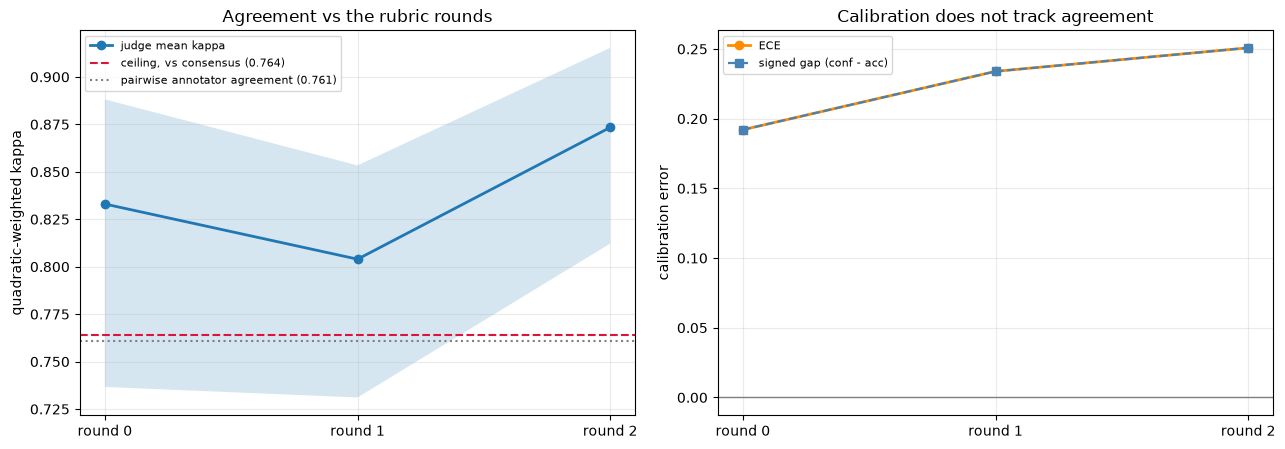

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
rounds = ["round 0: bare rubric", "round 1: scale defined", "round 2: + few-shot"]

xs = range(len(rounds))
axes[0].plot(xs, [results[r]["kappa"]["mean"] for r in rounds], "o-", lw=2, label="judge mean kappa")
axes[0].fill_between(xs,
                     [results[r]["kappa"]["ci95"][0] for r in rounds],
                     [results[r]["kappa"]["ci95"][1] for r in rounds], alpha=0.18)
axes[0].axhline(ceil["consensus_mean"], ls="--", color="crimson",
                label=f"ceiling, vs consensus ({ceil['consensus_mean']:.3f})")
axes[0].axhline(ceil["pairwise_mean"], ls=":", color="gray",
                label=f"pairwise annotator agreement ({ceil['pairwise_mean']:.3f})")
axes[0].set_xticks(list(xs)); axes[0].set_xticklabels(["round 0", "round 1", "round 2"])
axes[0].set_ylabel("quadratic-weighted kappa"); axes[0].set_title("Agreement vs the rubric rounds")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

axes[1].plot(xs, [results[r]["cal"].ece for r in rounds], "o-", lw=2, color="darkorange", label="ECE")
axes[1].plot(xs, [results[r]["cal"].signed_gap for r in rounds], "s--", lw=1.6, color="steelblue",
             label="signed gap (conf - acc)")
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_xticks(list(xs)); axes[1].set_xticklabels(["round 0", "round 1", "round 2"])
axes[1].set_ylabel("calibration error"); axes[1].set_title("Calibration does not track agreement")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 5. Is the baseline already good enough?

Three questions decide whether to fine-tune at all, and it is cheaper to answer them now than
after a training run.

1. **Is kappa near the ceiling?** If it is, there is nothing left to buy — further gains are
   annotator noise, not signal.
2. **Is the judge calibrated?** Look at the reliability curve, not the scalar.
3. **What does it cost per 1k judgments?** This is what a fine-tune is actually competing against.

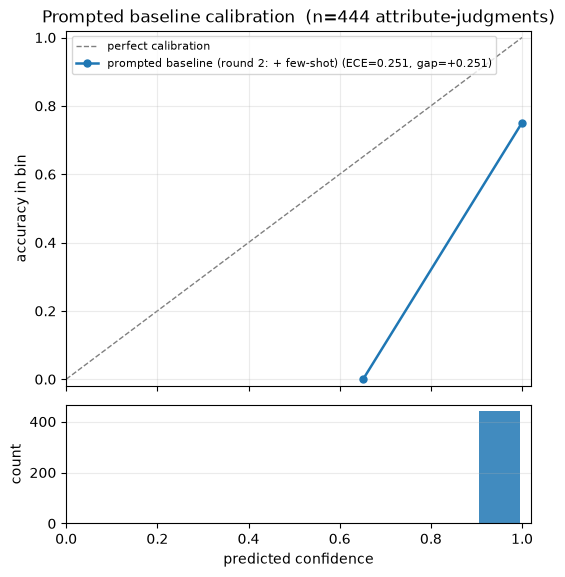

mean kappa      +0.873   ceiling +0.764   (114% of the ceiling)
ECE             0.251  (signed +0.251, worst bin 0.651)
mean confidence 0.999 vs accuracy 0.748
latency p50     3.14s   p95 14.70s
cost            $1.50 per 1k judgments (1911 in / 206 out)

STOP AND READ: the prompted baseline already matches or exceeds the annotator ceiling.
On agreement there is nothing left for a fine-tune to buy -- any further kappa gain is
noise-fitting. Fine-tuning can still be worth it for the latency and cost columns, and
for removing a 7k-character prompt from every call. Judge it on those, not on kappa.


In [12]:
best = results[BEST_ROUND]
jm.reliability_curve({f"prompted baseline ({BEST_ROUND})": best["cal"]},
                     title=f"Prompted baseline calibration  (n={best['cal'].n} attribute-judgments)")
plt.show()

print(f"mean kappa      {best['kappa']['mean']:+.3f}   ceiling {ceil['mean']:+.3f}   "
      f"({best['kappa']['mean'] / ceil['mean']:.0%} of the ceiling)")
print(f"ECE             {best['cal'].ece:.3f}  (signed {best['cal'].signed_gap:+.3f}, "
      f"worst bin {best['cal'].mce:.3f})")
print(f"mean confidence {best['cal'].mean_confidence:.3f} vs accuracy {best['cal'].accuracy:.3f}")
print(f"latency p50     {best['cost']['p50_latency_s']:.2f}s   p95 {best['cost']['p95_latency_s']:.2f}s")
print(f"cost            ${best['cost']['usd_per_1k']:.2f} per 1k judgments "
      f"({best['cost']['mean_prompt_tokens']:.0f} in / {best['cost']['mean_completion_tokens']:.0f} out)")

if best["kappa"]["mean"] >= ceil["mean"]:
    print("\nSTOP AND READ: the prompted baseline already matches or exceeds the annotator "
          "ceiling.\nOn agreement there is nothing left for a fine-tune to buy -- any further "
          "kappa gain is\nnoise-fitting. Fine-tuning can still be worth it for the latency and "
          "cost columns, and\nfor removing a 7k-character prompt from every call. Judge it on "
          "those, not on kappa.")

## 6. Fine-tune the judge

The training target is the panel's gold label. Two deliberate choices:

**The tuned judge gets a lean prompt.** The baseline keeps whichever round scored best — its full
prompt, however long — while the tuned model gets the bare rubric. That is the same fairness
convention as the `sft_prompt_router` case study: prompt-engineered base versus fine-tuned model on
a short prompt. When the winning round is a long few-shot prompt, this is also where the cost win
comes from, since the fine-tune moves the rubric out of the prompt and into the weights. When the
winning round is round 0, there is no prompt to save and the fine-tune has to justify itself on
model size alone.

**A calibration split is carved out of train, not holdout.** Temperature scaling in section 7 has
to be fit on data the holdout never sees, or the reported ECE is a fit statistic rather than a
measurement.

### Where a judge's uncertainty actually comes from

Every training row is a rigid `{"correctness": 3, "efficiency": 5, "tool_use": 5}`. No soft targets,
no probabilities. So how can the model possibly learn *when to be unsure*?

From the inconsistency **across** rows, not within them. Cross-entropy has a property that is easy
to miss: when the same input maps to different labels in the training set, the loss is not minimized
by picking one — it is minimized by predicting the **frequencies**. Show a model six near-identical
traces labelled `3, 3, 1, 3, 1, 3` and it cannot do better than roughly `p(3)=0.67, p(1)=0.33`. That
distribution is the calibration, and it was reverse-engineered from disagreement.

Which means taking the median before training actively destroys the signal — a median is a denoising
step. So we train **both** ways and compare (`LABEL_MODES` in the config cell): `median` gives one
row per trace, `votes` gives one row per annotator with the same prompt and deliberately conflicting
targets. Same traces, 3× the rows, and the ambiguity attached to the *specific* trace rather than
averaged over the trace type.

The two variants are trained, deployed, evaluated, and torn down one at a time, against the same
holdout. Nothing needs to be re-run to see both.

The measurable difference to look for in section 7 is **`TV contested`** — distance between the
judge's distribution and the panel's, restricted to traces the annotators split on. Median-training
can produce a judge that is well calibrated in aggregate and still no better at spotting *which*
cases are hard. Watch whether votes moves it, and watch what it costs in kappa: hedging on a
contested trace means sometimes landing on the wrong side of a boundary you used to get right.

**What we measured, across two model sizes.** Both effects are real, and both depend on capacity:

| | 4B median | 4B votes | 35B median | 35B votes |
| --- | --- | --- | --- | --- |
| kappa | +0.952 | +0.759 | +0.977 | +0.921 |
| TV contested | 0.470 | 0.338 | 0.394 | 0.287 |

Three things to take from it. **Votes wins on uncertainty at both sizes** — that is the mechanism
above doing its job. **The kappa it costs shrinks with capacity**, from −0.193 at 4B to −0.056 at
35B, so a small model has to choose between matching the label and matching the doubt while a
larger one mostly does not. And **median-training is not uniformly useless**: at 4B it left
`TV contested` exactly where the prompted baseline was (0.470 vs 0.471), while at 35B it recovered a
good part of the gap on its own. Capacity substitutes for the signal; it does not replace it.

A caveat on the kappa column: in the 35B run both variants scored *above* the annotator ceiling, so
those numbers say more about fitting the panel than about judging well. When that happens, decide on
`TV contested` and cost.

In [13]:
# Lean prompt: what the tuned model is trained on, and evaluated with.
LEAN = RUBRIC_INTRO + JSON_TAIL

rng = np.random.default_rng(42)
order = rng.permutation(len(labeled))
n_hold = max(4, int(0.25 * len(labeled)))
n_calib = max(4, int(0.15 * len(labeled)))
assert n_hold + n_calib < len(labeled), "gold set too small to split; raise N_TRACES"

hold_idx  = set(order[:n_hold].tolist())
calib_idx = set(order[n_hold:n_hold + n_calib].tolist())
train_idx = set(order[n_hold + n_calib:].tolist())

holdout_recs = [labeled[i] for i in sorted(hold_idx)]
calib_recs   = [labeled[i] for i in sorted(calib_idx)]
train_recs   = [labeled[i] for i in sorted(train_idx)]


def sft_rows(rec, mode):
    """Training rows for one trace, under one label mode.

    `median`  one row per trace, labelled with the panel median. The obvious choice,
              and it throws away two thirds of the signal -- taking a median is a
              denoising step, so the model never sees that the annotators argued.

    `votes`   one row per annotator, same prompt, *disagreeing* labels. Nothing here
              is a soft target; every row is still a rigid 1-5. But cross-entropy over
              inconsistent labels for the same input is minimized by predicting the
              label *frequencies*, so the disagreement is what teaches the model when
              to be unsure. This is where a judge's calibration actually comes from.
    """
    prompt = label_panel.build_user_prompt(rec)

    def _row(scores):
        return {"messages": [
            {"role": "system", "content": LEAN},
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": json.dumps(scores)},
        ]}

    if mode == "votes":
        return [_row({a: rec["panel"][p][a] for a in ATTRIBUTES}) for p in sorted(rec["panel"])]
    return [_row(rec["gold"])]


with open(HOLDOUT_FILE, "w") as f:
    for r in holdout_recs:
        f.write(json.dumps(sft_rows(r, "median")[0], ensure_ascii=False) + "\n")

n_rows = {}
for mode in LABEL_MODES:
    with open(train_file(mode), "w") as f:
        for r in train_recs + calib_recs:
            for row in sft_rows(r, mode):
                f.write(json.dumps(row, ensure_ascii=False) + "\n")
    n_rows[mode] = sum(len(sft_rows(r, mode)) for r in train_recs + calib_recs)

print(f"{len(train_recs) + len(calib_recs)} training traces "
      f"({len(calib_recs)} reserved for temperature fitting), {len(holdout_recs)} holdout")
for mode in LABEL_MODES:
    print(f"  {mode:<7s} -> {n_rows[mode]:>4d} rows, {EPOCHS[mode]} epochs   {train_file(mode).name}")

contested = [r for r in train_recs
             if any(len({r["panel"][p][a] for p in r["panel"]}) > 1 for a in ATTRIBUTES)]
print(f"\n{len(contested)}/{len(train_recs)} training traces carry disagreeing labels. Those are "
      f"the ones that\nteach hedging -- and 'median' collapses every one of them to a single "
      f"answer. Example:")
if contested:
    print("   median mode:")
    print("     ", contested[0]["gold"])
    print("   votes mode (same prompt, three targets):")
    for row in sft_rows(contested[0], "votes"):
        print("     ", row["messages"][-1]["content"])

144 training traces (28 reserved for temperature fitting), 48 holdout
  median  ->  144 rows, 3 epochs   judge_train_median.jsonl
  votes   ->  432 rows, 2 epochs   judge_train_votes.jsonl

68/116 training traces carry disagreeing labels. Those are the ones that
teach hedging -- and 'median' collapses every one of them to a single answer. Example:
   median mode:
      {'correctness': 3, 'efficiency': 5, 'tool_use': 5}
   votes mode (same prompt, three targets):
      {"correctness": 3, "efficiency": 5, "tool_use": 5}
      {"correctness": 3, "efficiency": 5, "tool_use": 4}
      {"correctness": 3, "efficiency": 5, "tool_use": 5}


In [14]:
# Re-measure the prompted baseline on the SAME holdout the tuned judge will see.
# Comparing a tuned model on a holdout against a baseline measured on a different set
# is the single easiest way to manufacture a fake improvement.
print(f"baseline prompt: {BEST_ROUND}\n")
print(jm.HEADER)
print("-" * 96)
_ = evaluate("BASELINE (holdout)", BASELINE_JUDGE, BEST_PROMPT, records=holdout_recs,
             price_key=BASELINE_JUDGE)

baseline prompt: round 2: + few-shot

judge                      mean kappa [95% CI]    ECE (signed)         latency / cost
------------------------------------------------------------------------------------------------
BASELINE (holdout)         +0.845 [+0.71,+0.91]  ECE=0.346 (+0.346)  p50=2.91s  $1.55/1k
                           parse=100%  brier=0.692 (rel=0.339 res=0.280)  TV_contested=0.604


### Confirmation gate

Everything above is inference only. The next cell prints the resolved plan; the cell after it
**creates billable resources**. Read the plan, then set `CONFIRMED = True`.

In [15]:
_plan = "\n".join(
    f"""  [{mode}]        dataset accounts/{ACCOUNT_ID}/datasets/{res_id(mode)}
                 {n_rows[mode]} rows from {len(train_recs) + len(calib_recs)} traces, epochs={EPOCHS[mode]}
                 model   accounts/{ACCOUNT_ID}/models/{res_id(mode)}
                 deploy  {res_id(mode)}"""
    for mode in LABEL_MODES)

print(f"""
RESOLVED PLAN
=============
account            accounts/{ACCOUNT_ID}
method             managed LoRA SFT (supervised_fine_tuning_jobs) + on-demand deployment
base model         {STUDENT_MODEL}
variants           {len(LABEL_MODES)} trained and evaluated in sequence:
{_plan}
dataset format     CHAT; messages[system(lean rubric), user(task+answer+trace), assistant(scores JSON)]
labels             3-annotator panel ({PANEL_MODEL}); 'median' = consensus label,
                   'votes' = one row per annotator, disagreement preserved
holdout            {len(holdout_recs)} traces, never seen by any trainer, identical across variants
set explicitly     lora_rank={LORA_RANK} lr={LEARNING_RATE} batch={BATCH_SIZE_SAMPLES}
                   training V2 (required by recent base models; falls back to V1 for old ones)
left to backend    region, trainer shape, node/accelerator count for training
deployment         {ACCELERATOR_COUNT}x {ACCELERATOR_TYPE}, replicas=1. ONE AT A TIME -- each variant
                   is torn down before the next is deployed, so you never pay for two
success metric     mean quadratic-weighted kappa on the holdout vs the prompted baseline
                   ({results['BASELINE (holdout)']['kappa']['mean']:+.3f}), read against the
                   annotator ceiling ({ceil['consensus_mean']:+.3f}); plus ECE, TV-contested,
                   p50 latency and $/1k
cost               {len(LABEL_MODES)} LoRA jobs on a {SIZE} model, plus GPU-hour on one
                   {ACCELERATOR_TYPE} for as long as each deployment is up
resume             ids derive from RUN={RUN}; re-run with JUDGE_ALIGN_RUN={RUN} to reuse them
teardown           each variant tears down after its eval; the last cell is a safety net
""")

# Set this to True (or export JUDGE_ALIGN_CONFIRM=1) once you have read the plan above.
CONFIRMED = True#os.getenv("JUDGE_ALIGN_CONFIRM") == "1"
print("CONFIRMED =", CONFIRMED)


RESOLVED PLAN
account            accounts/pyroworks
method             managed LoRA SFT (supervised_fine_tuning_jobs) + on-demand deployment
base model         accounts/fireworks/models/qwen3p6-35b-a3b
variants           2 trained and evaluated in sequence:
  [median]        dataset accounts/pyroworks/datasets/judge-align-35b-median-c9178b
                 144 rows from 144 traces, epochs=3
                 model   accounts/pyroworks/models/judge-align-35b-median-c9178b
                 deploy  judge-align-35b-median-c9178b
  [votes]        dataset accounts/pyroworks/datasets/judge-align-35b-votes-c9178b
                 432 rows from 144 traces, epochs=2
                 model   accounts/pyroworks/models/judge-align-35b-votes-c9178b
                 deploy  judge-align-35b-votes-c9178b
dataset format     CHAT; messages[system(lean rubric), user(task+answer+trace), assistant(scores JSON)]
labels             3-annotator panel (accounts/fireworks/models/deepseek-v4-pro); 'median' = cons

In [16]:
assert CONFIRMED, "Set CONFIRMED = True in the cell above after reading the plan."


def wait_until(get_fn, ok, bad, label, every=30, tries=240):
    for i in range(tries):
        obj = get_fn()
        st = getattr(obj, "state", None)
        print(f"[{label}] {i + 1:03d} state={st}")
        if st in ok:
            return obj
        if st in bad:
            raise RuntimeError(f"{label} failed: state={st}")
        time.sleep(every)
    raise TimeoutError(f"{label} did not finish after {tries} polls")


def upload_dataset(ds_id, path, fmt="CHAT"):
    n = sum(1 for line in open(path, encoding="utf-8") if line.strip())
    try:
        client.datasets.create(dataset_id=ds_id, dataset={"format": fmt, "example_count": n})
        client.datasets.upload(dataset_id=ds_id, file=file_from_path(path))
    except Exception as exc:
        if "exists" not in str(exc).lower():
            raise
        print(f"dataset {ds_id} already exists, reusing")
    wait_until(lambda: client.datasets.get(ds_id), {"READY"}, {"STATE_UNSPECIFIED"},
               "dataset", every=3, tries=200)
    return f"accounts/{ACCOUNT_ID}/datasets/{ds_id}"


def create_sft_job(dataset_name, model_id, epochs):
    """Create the SFT job, preferring training V2.

    Some base models reject V1 outright ("managed SFT Training V1 is no longer supported;
    model ... must have use_training_v2=true"). The installed SDK has no
    `use_training_v2` parameter, so the flag goes through `extra_body`.

    The wire name is `use_training_v2`, snake_case -- unlike every other field on this
    endpoint, which is camelCase. Not worth guessing: try snake, then camel, then plain
    V1, so the notebook works across base-model generations either way.
    """
    common = dict(
        dataset=dataset_name,
        base_model=STUDENT_MODEL,
        output_model=f"accounts/{ACCOUNT_ID}/models/{model_id}",
        epochs=epochs,
        lora_rank=LORA_RANK,
        learning_rate=LEARNING_RATE,
        batch_size_samples=BATCH_SIZE_SAMPLES,
        eval_auto_carveout=True,
    )
    attempts = [("V2", {"use_training_v2": True}),
                ("V2 (camel)", {"useTrainingV2": True}),
                ("V1", None)]
    last = None
    for name, extra in attempts:
        try:
            job = client.supervised_fine_tuning_jobs.create(
                **common, **({"extra_body": extra} if extra else {}))
            print(f"  SFT job (training {name}): {job.name}")
            return job
        except Exception as exc:
            last = exc
            msg = str(exc)
            # "unknown field" means this spelling is not supported; anything else
            # (quota, bad dataset, model not tunable) should surface immediately.
            if "unknown field" not in msg and "training_v2" not in msg.lower():
                raise
            print(f"  {name} rejected: {msg[:110]}")
    raise last


def teardown(dep_id):
    """Delete, or scale to zero if Fireworks blocks the delete during its traffic cooldown."""
    try:
        client.deployments.delete(dep_id, ignore_checks=True)
        print(f"  deleted deployment {dep_id}")
    except Exception as exc:
        try:
            client.deployments.scale(dep_id, replica_count=0)
            print(f"  scaled to 0 (delete blocked, delete after cooldown): {dep_id}")
        except Exception as exc2:
            print(f"  could not tear down {dep_id}: {str(exc2)[:160]}")


def train_deploy_eval(mode):
    """One variant, end to end, torn down before returning.

    Deliberately sequential: two on-demand deployments up at once doubles the GPU bill
    for no benefit, since the holdout is identical and the evals do not interact.
    """
    rid = mode_id = res_id(mode)
    label = f"TUNED {variant(mode)}"
    print(f"\n{'=' * 70}\n{label}\n{'=' * 70}")

    ds = upload_dataset(mode_id, train_file(mode))
    job = create_sft_job(ds, mode_id, EPOCHS[mode])
    wait_until(lambda: client.supervised_fine_tuning_jobs.get(job.name.split("/")[-1]),
               {"JOB_STATE_COMPLETED"}, {"JOB_STATE_FAILED", "JOB_STATE_CANCELLED"},
               f"sft/{mode}")

    dep = client.deployments.create(
        base_model=f"accounts/{ACCOUNT_ID}/models/{mode_id}",
        deployment_id=rid,
        accelerator_type=ACCELERATOR_TYPE,
        accelerator_count=ACCELERATOR_COUNT,
        min_replica_count=1,
        max_replica_count=1,
    )
    dep_id = dep.name.split("/")[-1]
    deployed = False
    try:
        wait_until(lambda: client.deployments.get(dep_id), {"READY"}, {"FAILED"},
                   f"deploy/{mode}", every=15, tries=160)
        deployed = True
        infer = f"accounts/{ACCOUNT_ID}/deployments/{dep_id}"

        # READY is not proof of serving. Two things must work before the eval means anything:
        # a real 200, and top_logprobs alongside the constrained JSON -- without the second,
        # every calibration number in section 7 silently collapses to a one-hot fallback.
        smoke = judge_client.judge_once(
            oai, infer, LEAN, label_panel.build_user_prompt(holdout_recs[0]), ATTRIBUTES,
            max_tokens=TUNED_MAX_TOKENS, stop=TUNED_STOP)
        print(f"  smoke: {smoke.scores}  {smoke.latency_s:.2f}s  "
              f"{smoke.completion_tokens} out-tokens")
        assert smoke.ok, f"{label} returned no parseable scores: {smoke.raw[:300]}"
        assert not smoke.dist_is_fallback, (
            f"{label}: no usable top_logprobs, calibration would be meaningless.")
        if smoke.completion_tokens >= TUNED_MAX_TOKENS:
            print(f"  NOTE: hit the {TUNED_MAX_TOKENS}-token cap despite stop={TUNED_STOP}; "
                  f"latency and $/1k are upper bounds.")

        evaluate(label, infer, LEAN, records=holdout_recs, price_key="deployed",
                 max_tokens=TUNED_MAX_TOKENS, stop=TUNED_STOP)

        # Score the calibration split now, while the deployment is still up -- section 7
        # fits a temperature on it after everything has been torn down.
        ck, co = run_judge(calib_recs, oai, infer, LEAN, ATTRIBUTES, concurrency=CONCURRENCY,
                           max_tokens=TUNED_MAX_TOKENS, stop=TUNED_STOP)
        results[label]["calib"] = jm.flatten([o.dists for o in co],
                                             [r["gold"] for r in ck], ATTRIBUTES)
        results[label]["mode"] = mode
        return label
    finally:
        # Only tear down a deployment that actually served. A FAILED one costs nothing
        # (it never came up) and deleting it destroys the only copy of why it failed --
        # the shard logs and the serving-engine error live on the deployment record.
        if deployed:
            teardown(dep_id)
        else:
            print(f"  LEFT IN PLACE for diagnosis: {dep_id}\n"
                  f"  It is not serving, so it is not billing. Inspect it, then delete with:\n"
                  f"      client.deployments.delete('{dep_id}', ignore_checks=True)")


print(jm.HEADER)
print("-" * 96)
tuned_labels = [train_deploy_eval(mode) for mode in LABEL_MODES]
print("\nvariants evaluated:", tuned_labels)

judge                      mean kappa [95% CI]    ECE (signed)         latency / cost
------------------------------------------------------------------------------------------------

TUNED 35b-median
[dataset] 001 state=READY
  V2 rejected: Error code: 400 - {'code': 3, 'details': [], 'message': 'proto: (line 1:292): unknown field "use_training_v2"'
  V2 (camel) rejected: Error code: 400 - {'code': 3, 'details': [], 'message': 'proto: (line 1:292): unknown field "useTrainingV2"'}
  SFT job (training V1): accounts/pyroworks/supervisedFineTuningJobs/jjmzsh6x
[sft/median] 001 state=JOB_STATE_RUNNING
[sft/median] 002 state=JOB_STATE_RUNNING
[sft/median] 003 state=JOB_STATE_RUNNING
[sft/median] 004 state=JOB_STATE_RUNNING
[sft/median] 005 state=JOB_STATE_RUNNING
[sft/median] 006 state=JOB_STATE_RUNNING
[sft/median] 007 state=JOB_STATE_RUNNING
[sft/median] 008 state=JOB_STATE_RUNNING
[sft/median] 009 state=JOB_STATE_RUNNING
[sft/median] 010 state=JOB_STATE_RUNNING
[sft/median] 011 state=JOB

## 7. Compare on all three axes

Now the trade is visible. Kappa read against the ceiling, calibration read off the diagram, and
cost read per 1k judgments.

In [17]:
base_h = results["BASELINE (holdout)"]
shown = [("prompted baseline", base_h)] + [(lbl, results[lbl]) for lbl in tuned_labels]

print(f"{'':<22s} {'kappa':>18s} {'ECE':>16s} {'Brier rel':>10s} {'TV contested':>13s} "
      f"{'p50 s':>8s} {'$/1k':>8s}")
print("-" * 102)
for name, r in shown:
    ci = r["kappa"]["ci95"]
    print(f"{name:<22s} {r['kappa']['mean']:+.3f} [{ci[0]:+.2f},{ci[1]:+.2f}] "
          f"{r['cal'].ece:>8.3f} ({r['cal'].signed_gap:+.3f}) {r['brier']['reliability']:>10.3f} "
          f"{r['tv']['tv_contested']:>13.3f} {r['cost']['p50_latency_s']:>8.2f} "
          f"{r['cost']['usd_per_1k']:>8.2f}")
print("-" * 102)
print(f"{'annotator ceiling':<22s} {ceil['consensus_mean']:+.3f}")

for lbl in tuned_labels:
    r = results[lbl]
    print(f"\n{lbl} vs baseline:  kappa {r['kappa']['mean'] - base_h['kappa']['mean']:+.3f}   "
          f"ECE {r['cal'].ece - base_h['cal'].ece:+.3f}   "
          f"TV_contested {r['tv']['tv_contested'] - base_h['tv']['tv_contested']:+.3f}   "
          f"latency {r['cost']['p50_latency_s'] / base_h['cost']['p50_latency_s']:.2f}x")
    if r["kappa"]["mean"] > ceil["consensus_mean"]:
        print("  WARNING: above the annotator ceiling -- not a better judge, a judge fitting "
              "the panel.")

if len(tuned_labels) == 2:
    a, b = (results[l] for l in tuned_labels)
    print(f"""
median vs votes -- the trade this notebook exists to measure:
  kappa        {a['kappa']['mean']:+.3f} -> {b['kappa']['mean']:+.3f}   (does hedging cost argmax accuracy?)
  TV contested {a['tv']['tv_contested']:.3f} -> {b['tv']['tv_contested']:.3f}   (does it know WHICH traces are hard?)
  signed gap   {a['cal'].signed_gap:+.3f} -> {b['cal'].signed_gap:+.3f}   (+ overconfident, - underconfident)""")

                                    kappa              ECE  Brier rel  TV contested    p50 s     $/1k
------------------------------------------------------------------------------------------------------
prompted baseline      +0.845 [+0.71,+0.91]    0.346 (+0.346)      0.339         0.604     2.91     1.55
TUNED 35b-median       +0.977 [+0.91,+1.00]    0.026 (-0.017)      0.013         0.394     0.76     0.04
TUNED 35b-votes        +0.921 [+0.79,+0.98]    0.037 (-0.033)      0.077         0.287     0.73     0.04
------------------------------------------------------------------------------------------------------
annotator ceiling      +0.764

TUNED 35b-median vs baseline:  kappa +0.132   ECE -0.321   TV_contested -0.210   latency 0.26x

TUNED 35b-votes vs baseline:  kappa +0.076   ECE -0.309   TV_contested -0.317   latency 0.25x

median vs votes -- the trade this notebook exists to measure:
  kappa        +0.977 -> +0.921   (does hedging cost argmax accuracy?)
  TV contested 0.394 -

In [22]:
# Persist this variant so successive runs (4b/30b x median/votes) build a matrix
# rather than each one overwriting the last.
def _record(name, r, **extra):
    return dict(variant=name, kappa=r["kappa"]["mean"],
                ci_lo=r["kappa"]["ci95"][0], ci_hi=r["kappa"]["ci95"][1],
                ece=r["cal"].ece, signed_gap=r["cal"].signed_gap,
                brier_rel=r["brier"]["reliability"], tv_contested=r["tv"]["tv_contested"],
                p50=r["cost"]["p50_latency_s"], usd_per_1k=r["cost"]["usd_per_1k"],
                out_tokens=r["cost"]["mean_completion_tokens"], **extra)

rows = []
if RESULTS_FILE.exists():
    rows = [json.loads(l) for l in RESULTS_FILE.read_text().splitlines() if l.strip()]
for lbl in tuned_labels:
    rows.append(_record(variant(results[lbl]["mode"]), results[lbl],
                        base_model=STUDENT_MODEL, mode=results[lbl]["mode"], run=RUN))
rows.append(_record("prompted baseline", base_h, base_model=BASELINE_JUDGE, mode=None, run=RUN))
# Keep one baseline row (the most recent); dedupe by variant, newest wins.
seen, deduped = set(), []
for r in reversed(rows):
    if r["variant"] in seen:
        continue
    seen.add(r["variant"])
    deduped.append(r)
deduped.reverse()
RESULTS_FILE.write_text("\n".join(json.dumps(r) for r in deduped) + "\n")

print(f"{'variant':<22s} {'kappa':>8s} {'ECE':>8s} {'gap':>8s} {'Brier rel':>10s} "
      f"{'TV cont':>8s} {'p50 s':>7s} {'$/1k':>7s} {'out tok':>8s}")
print("-" * 96)
for r in sorted(deduped, key=lambda r: -r["kappa"]):
    print(f"{r['variant']:<22s} {r['kappa']:>+8.3f} {r['ece']:>8.3f} {r['signed_gap']:>+8.3f} "
          f"{r['brier_rel']:>10.3f} {r['tv_contested']:>8.3f} {r['p50']:>7.2f} "
          f"{r['usd_per_1k']:>7.2f} {r['out_tokens']:>8.0f}")
print("-" * 96)
print(f"{'annotator ceiling':<22s} {ceil['consensus_mean']:>+8.3f}")
print("""
Reading the matrix:
  kappa     does it pick the same score? Compare against the ceiling, not against zero.
  TV cont   does it hedge on the traces the annotators argued over? Votes-training wins
            here at every size. Median-training does nothing for it on a small model and
            only partly closes the gap on a large one -- capacity substitutes for the
            signal, it does not replace it.
  gap       sign matters: + is overconfident, - is underconfident.""")

variant                   kappa      ECE      gap  Brier rel  TV cont   p50 s    $/1k  out tok
------------------------------------------------------------------------------------------------
35b-median               +0.977    0.026   -0.017      0.013    0.394    0.76    0.04       21
35b-votes                +0.921    0.037   -0.033      0.077    0.287    0.73    0.04       22
prompted baseline        +0.845    0.346   +0.346      0.339    0.604    2.91    1.55      224
------------------------------------------------------------------------------------------------
annotator ceiling        +0.764

Reading the matrix:
  kappa     does it pick the same score? Compare against the ceiling, not against zero.
  TV cont   does it hedge on the traces the annotators argued over? Votes-training wins
            here at every size. Median-training does nothing for it on a small model and
            only partly closes the gap on a large one -- capacity substitutes for the
            signal, it

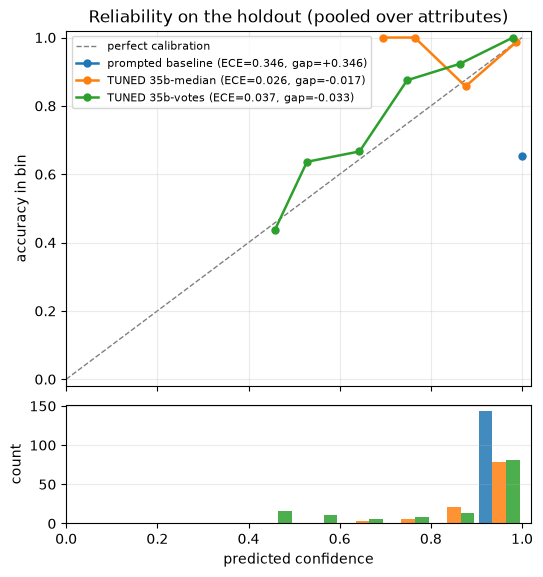

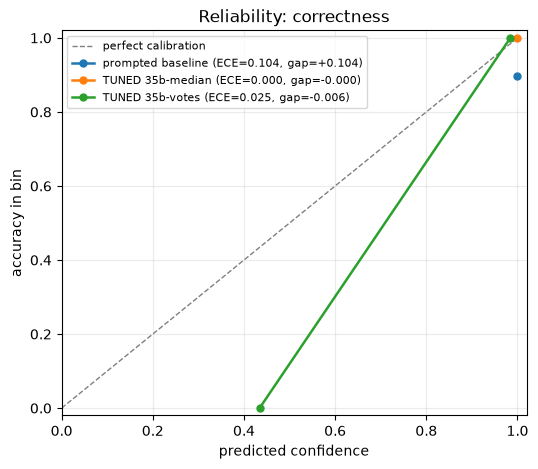

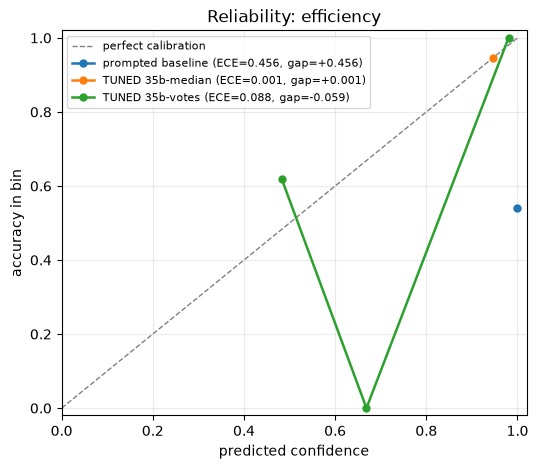

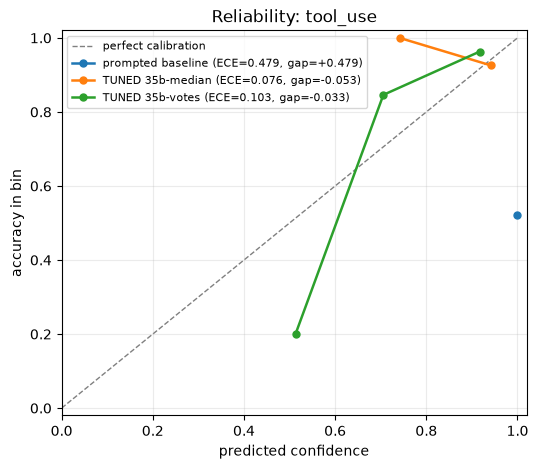

In [19]:
# The calibration story, overlaid. A curve sagging below the diagonal on the right is a judge
# that is confident and wrong -- the specific failure fine-tuning on argmax labels tends to cause.
_series = {"prompted baseline": base_h["cal"], **{l: results[l]["cal"] for l in tuned_labels}}
jm.reliability_curve(_series, title="Reliability on the holdout (pooled over attributes)")
plt.show()

for a in ATTRIBUTES:
    ai = ATTRIBUTES.index(a)
    def _slice(r):
        idx = np.arange(ai, len(r["y"]), len(ATTRIBUTES))
        return jm.ece_from(r["probs"][idx], r["y"][idx], n_bins=jm.suggest_bins(len(idx)))
    jm.reliability_curve({"prompted baseline": _slice(base_h),
                          **{l: _slice(results[l]) for l in tuned_labels}},
                         title=f"Reliability: {a}", show_counts=False)
    plt.show()


TUNED 35b-median
  fitted T = 0.913 on 63 calibration judgments (T > 1 softens, T < 1 sharpens)
  calibration split: ECE 0.036 -> 0.011   gap -0.017 -> -0.009
  holdout:           ECE 0.026 -> 0.024   gap -0.017 -> -0.009
  ADOPT -- improves calibration and leaves the argmax (so kappa) untouched.


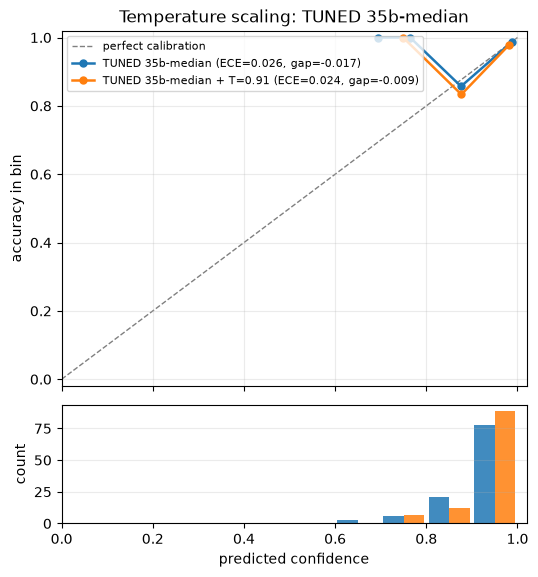


TUNED 35b-votes
  fitted T = 0.552 on 78 calibration judgments (T > 1 softens, T < 1 sharpens)
  calibration split: ECE 0.076 -> 0.021   gap -0.076 -> -0.016
  holdout:           ECE 0.037 -> 0.036   gap -0.033 -> +0.026
  ADOPT -- improves calibration and leaves the argmax (so kappa) untouched.


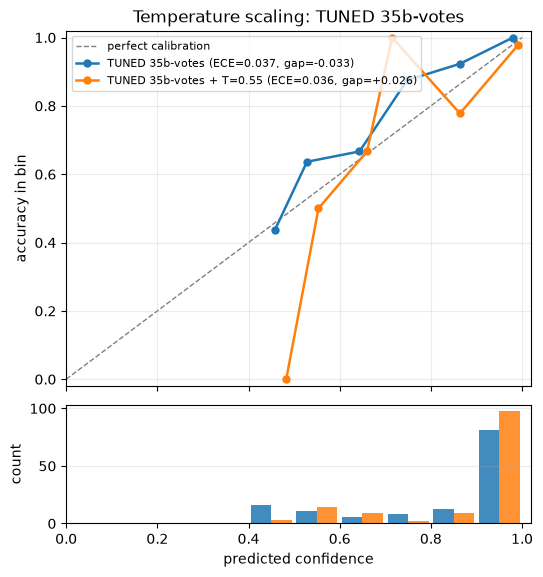

In [20]:
# Temperature scaling: one scalar per variant, fit on the calibration split the trainer
# saw but the holdout did not. Predictions were captured while each deployment was up,
# so nothing needs to be redeployed here.
for lbl in tuned_labels:
    r = results[lbl]
    calib_probs, calib_y = r["calib"]
    fit = jm.fit_temperature_guarded(calib_probs, calib_y, n_bins=jm.suggest_bins(len(calib_y)))
    T = fit["T"]
    cal_scaled = jm.ece_from(jm.apply_temperature(r["probs"], T), r["y"], n_bins=r["n_bins"])

    print(f"\n{lbl}")
    print(f"  fitted T = {T:.3f} on {fit['n']} calibration judgments "
          f"(T > 1 softens, T < 1 sharpens)")
    print(f"  calibration split: ECE {fit['ece_before']:.3f} -> {fit['ece_after']:.3f}"
          f"   gap {fit['gap_before']:+.3f} -> {fit['gap_after']:+.3f}")
    print(f"  holdout:           ECE {r['cal'].ece:.3f} -> {cal_scaled.ece:.3f}"
          f"   gap {r['cal'].signed_gap:+.3f} -> {cal_scaled.signed_gap:+.3f}")
    print("  ADOPT -- improves calibration and leaves the argmax (so kappa) untouched."
          if fit["adopt"] else
          "  DO NOT ADOPT -- worse on the split it was fitted on. Temperature scaling\n"
          "  minimizes NLL, not ECE; on an already-calibrated judge the optimum overshoots\n"
          "  and trades mild overconfidence for worse underconfidence. A signed gap that\n"
          "  flips sign is overcorrection, not a fix.")

    jm.reliability_curve({lbl: r["cal"], f"{lbl} + T={T:.2f}": cal_scaled},
                         title=f"Temperature scaling: {lbl}"
                               + ("" if fit["adopt"] else "  (NOT adopted)"))
    plt.show()

In [21]:
# TEARDOWN SAFETY NET. Each variant already tears itself down after its eval, so this
# should find nothing -- but run it anyway. An idle deployment bills by GPU-second, and
# a cell that failed between deploy and teardown leaves one running.
for mode in LABEL_MODES:
    teardown(res_id(mode))

try:
    mine = [d.name for d in client.deployments.list() if f"judge-align-" in d.name]
    print("\nremaining judge-align deployments:", mine or "none")
except Exception as exc:
    print("could not list deployments, check the console:", str(exc)[:120])

  could not tear down judge-align-35b-median-c9178b: Error code: 400 - {'code': 3, 'details': [], 'message': 'replica_count must be between min_replica_count (1) and max_replica_count (1)'}
  deleted deployment judge-align-35b-votes-c9178b

remaining judge-align deployments: ['accounts/pyroworks/deployments/judge-align-35b-med-4h100', 'accounts/pyroworks/deployments/judge-align-35b-votes-c9178b']


## What to take away

**Measure against the ceiling, not against zero.** The annotator agreement number printed in
section 3 is the ceiling for every judge below it. A fine-tuned judge that scores above it has
learned your panel's idiosyncrasies — including the ones your annotators would not defend. If your
prompted baseline is already close to the ceiling, a fine-tune buys you cost and latency, not
quality, and you should say so out loud rather than reporting a kappa delta.

**Matching the label is not matching the uncertainty, and the two move independently.** Kappa scores
the argmax; ECE scores the confidence. Fine-tuning can push either way and you cannot predict which
without measuring. Training on hard argmax targets is often said to drive a judge toward one-hot
outputs — but on our run the opposite happened: the tuned judge's ECE fell from 0.287 to 0.078 and
its Brier reliability improved nearly nine-fold, because it was trained on medians from a panel that
genuinely disagreed, and it learned to hedge where the panel hedged. A prompted frontier judge, by
contrast, sat at ~0.95 confidence on essentially everything. Whichever direction yours goes, it
matters the moment something downstream thresholds on judge confidence, routes low-confidence cases
to a human, or averages scores into a dashboard.

If calibration does regress, three fixes, cheapest first: temperature scaling (section 7 — but only
adopt it if it actually improves ECE on the calibration split, which it will not when the judge is
already close); training on the panel's soft distribution instead of the median; collecting more
annotators per trace so the soft label is worth fitting.

**Rubric drift is the real cost.** Updating a prompted judge is a text edit. Updating a fine-tuned
judge means relabeling the gold set, retraining, redeploying, and re-verifying calibration. Fine-tune
the judge once the rubric has stopped moving — and if section 4's round-over-round kappa is still
climbing steeply, the rubric has not stopped moving.

**Keep the gold set.** It outlives every judge you build on it, it is the only artifact here you
cannot regenerate, and it is what lets you answer "did the new judge get better or just different?"

### Next

- Point `label_panel.load()` at your own labeled traces; nothing downstream changes.
- Report per-attribute ceilings separately. Objective attributes (`correctness` here, where the
  annotators see the true answer) have high ceilings; subjective ones do not, and averaging them
  hides which half of your rubric is actually contested.
- Once the tuned judge clears your bar, wire it in as a reward function — see
  `agentic_rl_text2sql` and `reasoning_rl` for judges used that way in an RL loop.